In [10]:
from project1new import (
    Variable, 
    write_gph, 
    bayesian_score_component,
    prior,
    statistics,
    bayesian_score,
    K2Search
)
import numpy as np
import pandas as pd
import time
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
df_small = pd.read_csv("/Users/zzze/Desktop/AA228/project1/data/small.csv")
df_medium = pd.read_csv("/Users/zzze/Desktop/AA228/project1/data/medium.csv")
df_large = pd.read_csv("/Users/zzze/Desktop/AA228/project1/data/large.csv")

In [3]:
df_small.head()



,age,portembarked,fare,numparentschildren,passengerclass,sex,numsiblings,survived
0,1,1,1,1,1,1,1,1
1,2,2,1,1,2,2,1,2
2,1,1,1,1,1,2,1,2
3,2,1,1,1,2,2,1,2
4,2,1,1,1,1,1,1,1


In [4]:
df_small['sex'].unique()

array([1, 2])

In [5]:
df_medium.head()

,color,fixedacidity,volatileacidity,citricacid,residualsugar,chlorides,freesulfurdioxide,totalsulfurdioxide,density,pH,sulphates,alcohol,quality
0,2,4,5,1,2,5,1,1,5,4,1,2,3
1,2,4,5,1,3,5,3,2,4,2,2,3,3
2,2,4,5,1,2,5,1,1,4,3,2,3,3
3,2,5,3,5,2,5,2,1,5,2,2,3,4
4,2,4,5,1,2,5,1,1,5,4,1,2,3


In [6]:
df_large.head()

,WW,RE,HH,MU,YQ,DG,TV,YP,QZ,IB,...,UC,DW,FZ,KE,SD,US,UQ,JI,PM,XT
0,2,1,3,3,2,3,3,2,2,1,...,1,1,2,1,2,2,3,2,3,1
1,2,3,1,2,1,3,1,1,4,2,...,1,2,1,3,3,2,1,2,2,3
2,1,2,2,2,2,2,2,1,3,1,...,2,1,1,1,2,3,4,2,4,2
3,2,3,2,2,2,3,1,3,4,2,...,2,1,1,2,3,2,2,2,2,3
4,2,3,2,1,1,1,4,1,1,3,...,1,1,2,1,1,1,1,1,4,2


The general idea behind these types of scoring metrics is that you write the total score as the sum of node-local terms that depend only on a node and its parent set. What this means is that when you test a hypothetical edge 
X
→ Y
X→Y the only thing that is computed is the change in Y's total score. Because K2 only adds parents to a single child at any step given an ordering, nothing else in the graph should change.

In [ ]:
print("="*60)
print("Learning Bayesian Network Structure for small.csv")
print("="*60)

csv_path = "/Users/zzze/Desktop/AA228/project1/data/small.csv"
df = pd.read_csv(csv_path)

# Ensure 0..(r-1) integer encoding without changing the core functions
remap = {}
X = pd.DataFrame()
for c in df.columns:
    uniq = sorted(pd.unique(df[c]))
    mapping = {v:i for i,v in enumerate(uniq)}
    remap[c] = mapping
    X[c] = df[c].map(mapping).astype(int)

variables = [Variable(c, X[c].nunique()) for c in X.columns]
idx2name = {i:v.name for i,v in enumerate(variables)}

data = X.to_numpy().T  # shape (n_vars, n_samples)

ordering = list(range(len(variables)))  # column order

k2 = K2Search(ordering=ordering)

t0 = time.perf_counter()
graph = k2.fit(variables, data)
elapsed = time.perf_counter() - t0

score = bayesian_score(variables, graph, data)

# Write .gph next to the CSV using the provided function
out_path = Path(csv_path).with_suffix(".gph")
write_gph(graph, idx2name, str(out_path))

result = {
    "variables": [str(v) for v in variables],
    "edges": [(idx2name[u], idx2name[v]) for (u,v) in graph.edges()],
    "bayesian_score": float(score),
    "runtime_seconds": float(elapsed),
    "gph_file": str(out_path),
    "value_remap": remap
}
result

Learning Bayesian Network Structure for small.csv


{'variables': ['(age, 3)',
  '(portembarked, 3)',
  '(fare, 3)',
  '(numparentschildren, 3)',
  '(passengerclass, 3)',
  '(sex, 2)',
  '(numsiblings, 3)',
  '(survived, 2)'],
 'edges': [('age', 'numparentschildren'),
  ('age', 'passengerclass'),
  ('portembarked', 'passengerclass'),
  ('portembarked', 'sex'),
  ('fare', 'passengerclass'),
  ('fare', 'sex'),
  ('numparentschildren', 'sex'),
  ('numparentschildren', 'numsiblings'),
  ('passengerclass', 'survived'),
  ('sex', 'survived')],
 'bayesian_score': -3840.815191330504,
 'runtime_seconds': 3.230143042979762,
 'gph_file': '/Users/zzze/Desktop/AA228/project1/data/small.gph',
 'value_remap': {'age': {1: 0, 2: 1, 3: 2},
  'portembarked': {1: 0, 2: 1, 3: 2},
  'fare': {1: 0, 2: 1, 3: 2},
  'numparentschildren': {1: 0, 2: 1, 3: 2},
  'passengerclass': {1: 0, 2: 1, 3: 2},
  'sex': {1: 0, 2: 1},
  'numsiblings': {1: 0, 2: 1, 3: 2},
  'survived': {1: 0, 2: 1}}}

In [8]:
print("="*60)
print("Learning Bayesian Network Structure for large.csv")
print("="*60)

# start_time = time.time()
# dag, variables, idx2names = compute("/Users/zzze/Desktop/AA228/project1/data/small.csv", "/Users/zzze/Desktop/AA228/project1/data/small.gph")

# elapsed_time = time.time() - start_time
# print(f"\n Time taken: {elapsed_time:.2f} seconds")

csv_path = "/Users/zzze/Desktop/AA228/project1/data/medium.csv"
df = pd.read_csv(csv_path)

# Ensure 0..(r-1) integer encoding without changing the core functions
remap = {}
X = pd.DataFrame()
for c in df.columns:
    uniq = sorted(pd.unique(df[c]))
    mapping = {v:i for i,v in enumerate(uniq)}
    remap[c] = mapping
    X[c] = df[c].map(mapping).astype(int)

variables = [Variable(c, X[c].nunique()) for c in X.columns]
name2idx = {v.name:i for i,v in enumerate(variables)}
idx2name = {i:v.name for i,v in enumerate(variables)}

data = X.to_numpy().T  # shape (n_vars, n_samples)

ordering = list(range(len(variables)))  # column order

k2 = K2Search(ordering=ordering)

t0 = time.perf_counter()
graph = k2.fit(variables, data)
elapsed = time.perf_counter() - t0

score = bayesian_score(variables, graph, data)

out_path = Path(csv_path).with_suffix(".gph")
write_gph(graph, idx2name, str(out_path))

result = {
    "variables": [str(v) for v in variables],
    "edges": [(idx2name[u], idx2name[v]) for (u,v) in graph.edges()],
    "bayesian_score": float(score),
    "runtime_seconds": float(elapsed),
    "gph_file": str(out_path),
    "value_remap": remap
}
result

Learning Bayesian Network Structure for large.csv


{'variables': ['(color, 2)',
  '(fixedacidity, 5)',
  '(volatileacidity, 5)',
  '(citricacid, 5)',
  '(residualsugar, 5)',
  '(chlorides, 5)',
  '(freesulfurdioxide, 5)',
  '(totalsulfurdioxide, 5)',
  '(density, 5)',
  '(pH, 5)',
  '(sulphates, 5)',
  '(alcohol, 8)',
  '(quality, 7)'],
 'edges': [('color', 'volatileacidity'),
  ('color', 'citricacid'),
  ('color', 'residualsugar'),
  ('color', 'chlorides'),
  ('color', 'freesulfurdioxide'),
  ('color', 'totalsulfurdioxide'),
  ('color', 'density'),
  ('color', 'pH'),
  ('color', 'sulphates'),
  ('color', 'alcohol'),
  ('fixedacidity', 'citricacid'),
  ('fixedacidity', 'residualsugar'),
  ('fixedacidity', 'chlorides'),
  ('fixedacidity', 'pH'),
  ('residualsugar', 'freesulfurdioxide'),
  ('residualsugar', 'totalsulfurdioxide'),
  ('residualsugar', 'density'),
  ('residualsugar', 'alcohol'),
  ('chlorides', 'totalsulfurdioxide'),
  ('chlorides', 'density'),
  ('density', 'alcohol'),
  ('density', 'quality')],
 'bayesian_score': -100113.

In [ ]:
csv_path = "/Users/zzze/Desktop/AA228/project1/data/large.csv"
df = pd.read_csv(csv_path)
remap = {}
X = pd.DataFrame()
for c in df.columns:
    uniq = sorted(pd.unique(df[c]))
    mapping = {v:i for i,v in enumerate(uniq)}
    remap[c] = mapping
    X[c] = df[c].map(mapping).astype(int)

variables = [Variable(c, X[c].nunique()) for c in X.columns]
idx2name = {i:v.name for i,v in enumerate(variables)}
data = X.to_numpy().T  

ordering = list(range(len(variables)))  
k2 = K2Search(ordering=ordering)
t0 = time.perf_counter()
graph = k2.fit(variables, data)
elapsed = time.perf_counter() - t0
score = bayesian_score(variables, graph, data)

out_path = Path(csv_path).with_suffix(".gph")
write_gph(graph, idx2name, str(out_path))

result = {
    "variables": [str(v) for v in variables],
    "edges": [(idx2name[u], idx2name[v]) for (u,v) in graph.edges()],
    "bayesian_score": float(score),
    "runtime_seconds": float(elapsed),
    "gph_file": str(out_path),
    "value_remap": remap
}
result 

Learning Bayesian Network Structure for large.csv


{'variables': ['(WW, 2)',
  '(RE, 3)',
  '(HH, 3)',
  '(MU, 3)',
  '(YQ, 2)',
  '(DG, 3)',
  '(TV, 4)',
  '(YP, 3)',
  '(QZ, 4)',
  '(IB, 3)',
  '(IM, 3)',
  '(EY, 2)',
  '(QS, 4)',
  '(UN, 2)',
  '(NX, 3)',
  '(OF, 2)',
  '(FR, 3)',
  '(OG, 4)',
  '(MY, 2)',
  '(EV, 4)',
  '(YR, 3)',
  '(TU, 3)',
  '(UO, 2)',
  '(WF, 2)',
  '(JP, 2)',
  '(XQ, 2)',
  '(ME, 4)',
  '(CA, 2)',
  '(YH, 2)',
  '(WN, 2)',
  '(ZL, 4)',
  '(ND, 2)',
  '(GC, 3)',
  '(GS, 2)',
  '(BQ, 4)',
  '(ZX, 2)',
  '(VU, 2)',
  '(CZ, 3)',
  '(BX, 2)',
  '(RZ, 3)',
  '(UC, 4)',
  '(DW, 2)',
  '(FZ, 3)',
  '(KE, 3)',
  '(SD, 3)',
  '(US, 4)',
  '(UQ, 4)',
  '(JI, 2)',
  '(PM, 4)',
  '(XT, 3)'],
 'edges': [('WW', 'WF'),
  ('WW', 'GC'),
  ('RE', 'YQ'),
  ('RE', 'DG'),
  ('RE', 'IM'),
  ('RE', 'EY'),
  ('RE', 'QS'),
  ('RE', 'UN'),
  ('RE', 'EV'),
  ('RE', 'JP'),
  ('RE', 'YH'),
  ('RE', 'WN'),
  ('RE', 'ZX'),
  ('RE', 'UC'),
  ('RE', 'XT'),
  ('HH', 'EV'),
  ('HH', 'YR'),
  ('HH', 'FZ'),
  ('HH', 'JI'),
  ('HH', 'PM'),
  ('MU'

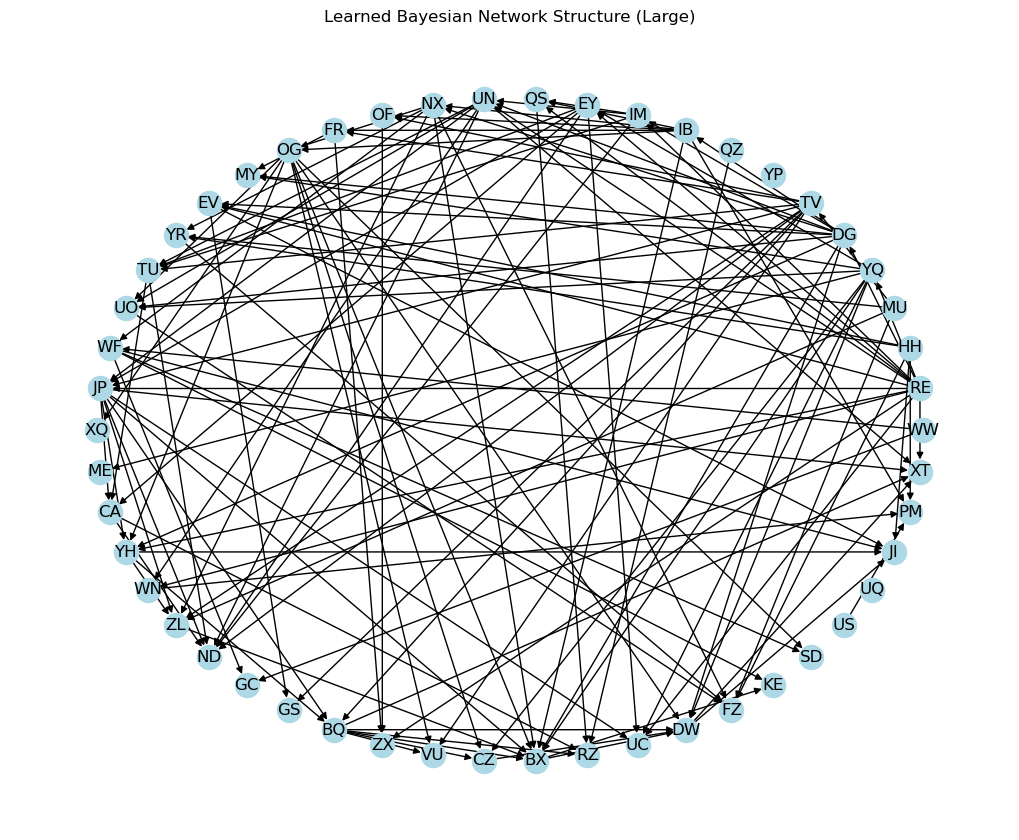

In [17]:

plt.figure(figsize=(10, 8))
pos = nx.circular_layout(graph)
nx.draw(
    graph,
    pos,
    with_labels=True,               
    labels=idx2name,                # show variable names instead of numeric IDs
    node_color="lightblue",         
    # node_size=7000,                 
    # font_size=10,                         
    arrows=True,                   
    # arrowsize=10,                   # arrow size  
    # width=2                         
)

plt.title("Learned Bayesian Network Structure (Large)")
plt.axis("off")
plt.show()
